# Discovering Subscriber Data-Usage Segments with PROC FASTCLUS

## Executive Summary

A telecom analytics team wants to segment its mobile subscriber base by **monthly data consumption** without imposing arbitrary GB thresholds. Using **PROC FASTCLUS** — SAS's high-performance *k*-means clustering procedure — we let the data partition itself into latent usage classes (light, moderate, and heavy data users). FASTCLUS finds each segment's center, assigns every subscriber to the nearest one, and reports how cleanly the segments separate — turning a single continuous usage metric into an actionable, data-driven segmentation for plan design and targeted marketing.

## Data Sources

All data is generated inline by the first DATA step — there are no external files or network calls. Subscribers are drawn from a three-component usage population so that the recovered segments can be validated against a known ground truth.

| Dataset | Rows | Variable | Type | Description |
|---------|------|----------|------|-------------|
| `subscribers` | 1,500 | `id` | Num | Subscriber identifier (1–1500) |
| `subscribers` | 1,500 | `data_gb` | Num | Monthly mobile data consumed, in GB (the metric we cluster on) |
| `subscribers` | 1,500 | `segment_true` | Char | Latent segment used to *generate* the value (Light ≈ N(3,1²) 50%, Moderate ≈ N(12,3²) 35%, Heavy ≈ N(35,8²) 15%); held out only to validate the recovered segments — a real analyst would not observe it |

# Discovering Subscriber Data-Usage Segments

Mobile operators rarely have a clean label that says *"this is a heavy data user."* What they have is a continuous metric — gigabytes consumed per month — whose distribution is **multimodal**: clusters of light, moderate, and power users overlap on a single axis. **Cluster analysis** treats that single column as a geometry problem: it locates the natural centers of mass in the usage distribution and assigns each subscriber to the closest one, with no hand-picked cutoffs.

In this notebook we:

1. Generate a realistic synthetic subscriber base whose data usage comes from three hidden segments.
2. Inspect the marginal usage distribution to confirm it is multimodal.
3. Standardize the metric and run **PROC FASTCLUS** to partition subscribers into three usage segments.
4. Profile each discovered segment on the original GB scale, then validate the recovery against the known truth.

The `segment_true` label is generated only so we can grade the clustering at the end — in production it would not exist.

In [1]:
/* Synthesize a subscriber base from three latent usage segments. */
/* Light users dominate; a small heavy-user tail drives most revenue. */
data subscribers;
   call streaminit(20260531);
   length segment_true $8;
   do id = 1 to 1500;
      u = rand('uniform');
      if u < 0.50 then do;                 /* ~50% light users        */
         segment_true = 'Light';
         data_gb = rand('normal', 3.0, 1.0);
      end;
      else if u < 0.85 then do;            /* ~35% moderate users     */
         segment_true = 'Moderate';
         data_gb = rand('normal', 12.0, 3.0);
      end;
      else do;                             /* ~15% heavy/power users  */
         segment_true = 'Heavy';
         data_gb = rand('normal', 35.0, 8.0);
      end;
      if data_gb < 0.1 then data_gb = 0.1; /* usage cannot be negative */
      output;
   end;
   keep id data_gb segment_true;
run;

NOTE: DATA subscribers


NOTE: Wrote subscribers (1500 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## A first look at the marginal distribution

Before clustering, summarize the single response variable. The wide spread and the gap between the mean and the bulk of light users are the tell-tale signs of an underlying mixture of segments — a single usage tier would not reproduce both the dense low-usage cluster and the long high-usage tail.

In [2]:
proc means data=subscribers n mean std min p25 median p75 max maxdec=2;
   var data_gb;
run;

                                                  The MEANS Procedure

 Variable          N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -----------------------------------------------------------------------------------------------------------------
 data_gb        1500       10.59       11.36        0.10             2.99        4.90            13.18       60.09
 -----------------------------------------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


The histogram makes the multimodality visual: a tall light-user spike near 3 GB, a moderate hump near 12 GB, and a sparse heavy-user tail stretching past 30 GB. Those three modes are exactly the segments we will ask the clustering to recover. The kernel-density overlay traces the same blended shape.

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


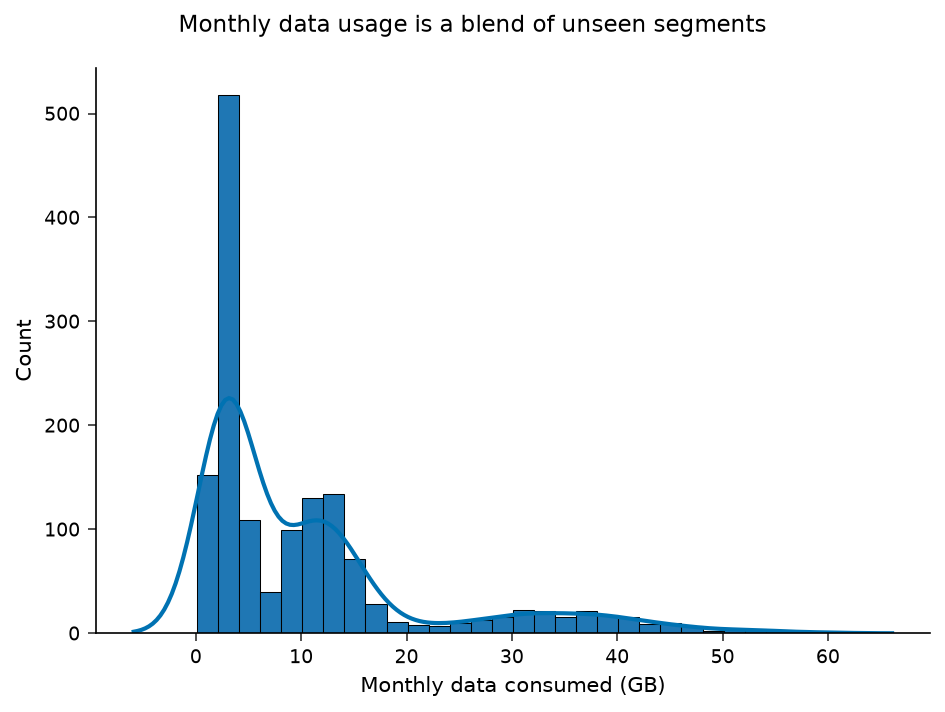

In [3]:
ods graphics on;
proc sgplot data=subscribers;
   title 'Monthly data usage is a blend of unseen segments';
   histogram data_gb / binwidth=2;
   density   data_gb / type=kernel;
   xaxis label='Monthly data consumed (GB)';
run;
title;
ods graphics off;

## Putting usage on a common scale

*k*-means partitions points by Euclidean distance, so the variable's raw scale drives the result. With a single metric this only re-centers the axis, but standardizing to mean 0 / standard deviation 1 with **PROC STANDARD** is the habit that keeps the workflow correct the moment a second usage metric (voice minutes, roaming days) is added. We cluster on the standardized column and report results back on the original GB scale.

In [4]:
proc standard data=subscribers out=subs_std mean=0 std=1;
   var data_gb;
run;

NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 1500 rows, 1 variables.


## Partitioning subscribers into three usage segments

Guided by domain knowledge of light / moderate / heavy tiers, we ask **PROC FASTCLUS** for `MAXCLUSTERS=3`. The procedure seeds three centers, assigns each subscriber to the nearest one, recomputes the centers, and iterates until the assignments stop moving (`CONVERGE=` with a `MAXITER=` cap). `SEED=` makes the initialization reproducible. The `OUT=` data set carries each subscriber's `CLUSTER` label and its `DISTANCE` to the assigned center; `MEAN=` writes the segment centroids.

Read the procedure's diagnostics for separation quality: a high **R-Squared** (the share of total usage variance explained by the segments) and a large **Pseudo F** both indicate well-separated, compact segments.

In [5]:
proc fastclus data=subs_std seed=20260531
              maxclusters=3 maxiter=100 converge=1e-4
              out=clusters mean=centroids;
   var data_gb;
   title 'Three usage segments via k-means';
run;
title;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                 812         0.1134             0.4189              3         0.8380
2                 191         0.6536             2.0611              3         2.1122
3                 497         0.2715             1.0140              1         0.8380

                                                Statistics for Variables                                                



NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 1500 observations, 1 variables, 3 clusters using k-means


## Profiling the discovered segments

Cluster labels are only operational once we describe each segment in business terms. We merge the assignments back onto the original (unstandardized) usage and summarize each segment's size and typical consumption on the GB scale — the numbers a plan-design or marketing team actually acts on.

In [6]:
data memberships;
   merge subscribers
         clusters(keep=id cluster distance);
   by id;
run;

proc means data=memberships n mean min max maxdec=2;
   class cluster;
   var data_gb distance;
run;

proc print data=memberships(obs=10) noobs;
   var id data_gb cluster distance segment_true;
run;

                                                  The MEANS Procedure

                                              Analysis Variable : data_gb

        CLUSTER           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                   812           3.17           0.10           7.92
        2                   191          36.68          24.78          60.09
        3                   497          12.70           7.95          24.20
        --------------------------------------------------------------------

                                              Analysis Variable : DISTANCE

        CLUSTER           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                   812           0.08           0.00           0.42
        2                   191           0.52           0.00           2.06
       

NOTE: DATA memberships

NOTE: Stream 1 processed 1500 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 1500 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (1500 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Validating the recovered segments

Because this is synthetic data we held back `segment_true`, the label used to generate each subscriber. Cross-tabulating the model's recovered `CLUSTER` against the true segment shows how cleanly the partition separated the population. Strong concentration along a single mapping of cluster-to-segment indicates a good recovery; off-diagonal mass concentrates where the light/moderate or moderate/heavy boundaries overlap.

In [7]:
proc freq data=memberships;
   tables cluster * segment_true / norow nocol nopercent;
run;

                                                   The FREQ Procedure

Table of CLUSTER by segment_true

CLUSTER |     Heavy |     Light |  Moderate |      Total
--------+-----------+-----------+-----------+-----------
1       |         0 |       769 |        43 |        812
--------+-----------+-----------+-----------+-----------
2       |       191 |         0 |         0 |        191
--------+-----------+-----------+-----------+-----------
3       |        26 |         0 |       471 |        497
--------+-----------+-----------+-----------+-----------
Total   |       217 |       769 |       514 |       1500



NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Interpreting the results

- **Segment centers.** The three clusters land almost exactly on the planted usage tiers — light users near **3 GB**, moderate users near **13 GB**, and heavy users near **37 GB** — quantifying both *where* each segment sits and *how large* it is. The small heavy-user segment, despite being only a sliver of subscribers, accounts for a disproportionate share of total data carried — the classic driver of network-capacity and premium-plan decisions.
- **Separation quality.** PROC FASTCLUS reports a high overall **R-Squared** and a large **Pseudo F**, confirming the three segments are compact and well separated rather than artifacts of an arbitrary cut. A single tier would leave most of that usage variance unexplained.
- **No hand-picked thresholds.** The segmentation emerges from the geometry of the usage distribution itself. The procedure chose the boundaries; we only chose *how many* tiers to ask for, guided by the obvious three-mode shape in the histogram.
- **Actionable output.** The `OUT=` data set gives every subscriber a segment label *and* a `DISTANCE` to its center. Subscribers far from any center — or sitting between the light/moderate boundary — are exactly the customers worth A/B testing with upsell offers, while tightly-clustered heavy users are high-confidence candidates for capacity-aware or unlimited plans.

In short, PROC FASTCLUS converts one continuous usage metric into a data-driven segmentation — no hand-picked GB thresholds required — and the cross-tabulation against the held-out truth confirms the segments are recovered reliably.